# Elección del dataset
Me llamo la atención este dataset porque tenía muchas columnas, nunca había trabajado con tantas columnas y menos del estilo de este dataset que es mucho categórico y quería saber como podía llevarlo a cabo. Y cuando el profe mencionó que este dataset estaba bueno como primera práctica, me cerró por todos lados. No es que me guste particularmente de que trata pero me interesa lo suficiente como para intentar comprenderlo y trabajar con él.

# Aclaración inicial
La idea es documentar el paso a paso junto con los avances, por más minimos que sean para poder comprender desde 0 todo el proceso. Lo primero entonces es analizar el porque del dataset, que información tiene y aparte generar una problemática con el objetivo de contextualizar el dataset y poder aplicarlo en una lógica de negocio mas realista con la esperanza de que me ayude a aplicar mejor los conceptos

# Planteo de hipotésis
Esta hipotésis fue cambiando mientras abalizaba el gráfico, primero pense en los que cierto género tiende a abandonar más la universiadad pero a medida que iba avanzando se me ocurrió o se me presentó la idea de que los hombres tienden a abandonar más la universidad cuando tienen  varios semestres desaprobados. Pero esto también me deja una duda, ¿Tiene que ver con la situación economica? ¿Con la situación en la que se encuentran? Por ahora esa es mi hipotésis pero no creo comprender realmente el potencial de análisis del dataset. Y en un futuro podría cambiar, así que pido que en la corrección me pueda guiar en la dirección correcta.

## Contextualización
Antes de hablar del objetivo, me gustaría establecer un contexto para ayudarme a entender el porque de las acciones. La situación es esta: la universidad tiene la intención de hacer una campaña para aumentar el número de graduados pero no sabe donde comenzar. Ahí es donde entramos nosotros, debemos comprender y ayudar a esta universidad a identificar un punto débil(si puede llamarse así) para que puede enfocar esta campaña y esta de sus frutos.
### Variables objetivos
Se me ocurrió utilizar el género, la edad en la que se inscribieron y si se graduaron, dejaron o siguen en curso que es nuestra variable más importante ya que es la que nos brinda la información más relevante para nuestro contexto. Gender, Age at enrollment y Target, respectivamente. Realmente creo que puede sacar valor en el contexto de la problemática y como vimos ejemplos de como se manejan las variables como el género me parece una buena opción como una primera aproximación. Esta es mi primera idea, voy a aplicar el primer análisis y luego de ver los resultados veré si volver a este punto de nuevo o no.

## Hacer diccionario
Esta parte esta para clarificar un poco las variables que tengo pensado utilizar, esto es para dejar en claro a que hacen referencias los números que representan a las categorías.
En el caso de edad no hay mucho que agregar.
Gender = {1 = male, 0= female}
Daytime/evening attendance = {1 = daytime, 0 = evening}
Por último al valor, target,  que es lo que nos dice si: DROPOUT(abandonó), GRADUATED(graduado) y ENROLLED(sigue en curso).
Target = {0 = DROPOUT, 1 = GRADUATED, 2 = ENROLLED}

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("coderhouse/Data Science I/Dropout.csv", sep =";")
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,0.150316,11.566139,1.228029,0.001969,0.858273
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,0.753774,2.663850,1.382711,2.269935,0.693326
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,0.000000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,0.000000,9.400000,0.300000,-1.700000,0.000000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,0.000000,11.100000,1.400000,0.320000,1.000000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,0.000000,13.900000,2.600000,1.790000,1.000000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,12.000000,16.200000,3.700000,3.510000,2.000000


In [4]:
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,"1,36667E+16",0,13.9,-0.3,0.79,1
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.4,0,9.4,-0.8,-3.12,1
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.0,0,13.9,-0.3,0.79,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,"1,26667E+16",0,15.5,2.8,-4.06,1
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.0,0,11.1,0.6,2.02,0
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.5,0,13.9,-0.3,0.79,0
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.0,0,9.4,-0.8,-3.12,1


## Gráfico de torta
La idea de este gráfico es analizar el porcentaje general de los alumnos graduados, dropouts y enrolled.

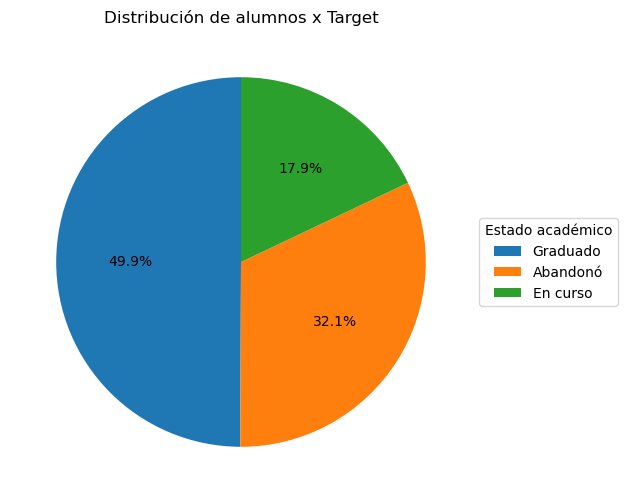

In [49]:
plt.figure(figsize =(12,6))
df["Target"].replace({
    0:"Dropout",
    1:"Graduate",
    2:"Enrolled"
}).value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=None,
    startangle=90
)

plt.legend(
   ["Graduado", "Abandonó", "En curso"],
    title="Estado académico",
    loc="center left",
    bbox_to_anchor=(1,0.5)
)

plt.ylabel("")
plt.title("Distribución de alumnos x Target")

plt.show()

Este lo hice con la idea de ver un poco la proporción por género ya que afecta al gráfico de barras posterior y me ayuda a entender un poco más como y porque se distribuyen los géneros

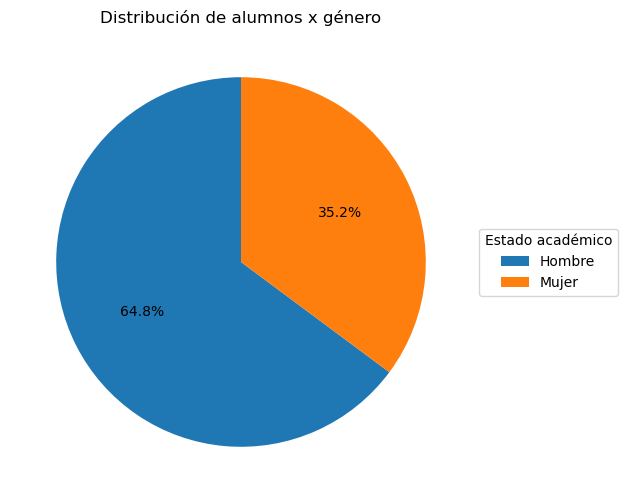

In [48]:
plt.figure(figsize =(12,6))
df["Gender"].replace({
    0:"Male",
    1:"Female"
}).value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=None,
    startangle=90
)

plt.legend(
   ["Hombre", "Mujer"],
    title="Estado académico",
    loc="center left",
    bbox_to_anchor=(1,0.5)
)

plt.ylabel("")
plt.title("Distribución de alumnos x género")

plt.show()

## Gráfico de barras
Mi idea con este gráfico es analizar la diferencia de género por la variable target para entender hacia donde deberíamos apuntar la solución. Hice este gráfico antes de los de torta, entonces luego de generar los de torta me di cuenta que este gráfico podría estar sesgado  por la diferencia en el porcentaje de género pero no se me ocurre como podría solucionarlo. Me gustaría una corrección si es el caso.

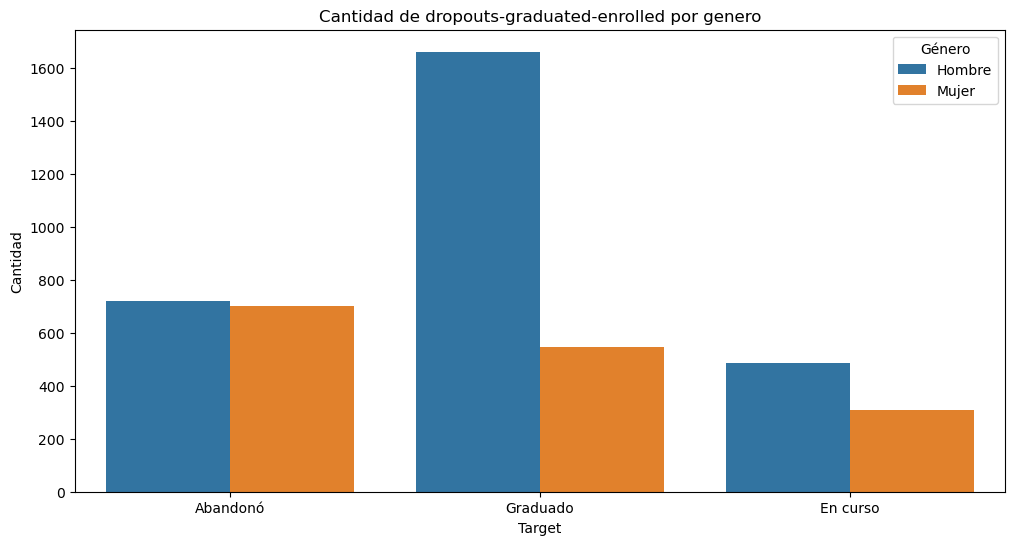

In [50]:
plt.figure(figsize =(12,6))
sns.countplot(data=df, x="Target", hue="Gender")
plt.title("Cantidad de dropouts-graduated-enrolled por genero")
plt.xlabel("Target")
plt.ylabel("Cantidad")
plt.xticks(
    [0,1,2],
    ["Abandonó","Graduado","En curso"]
)
plt.legend(
    title="Género",
    labels=["Hombre", "Mujer"]
)
plt.show()

## Histograma
El objetivo del gráfico es ver la distribución de edades teniendo en cuenta los géneros. Todos estos datos nos ayudan a orientar la publicidad que el contexto esta buscando. También me surgió una duda, porque en el siguiente gráfico de boxplot voy a utilizar las mismas variables pero busco identifcar específicamente los outliers.

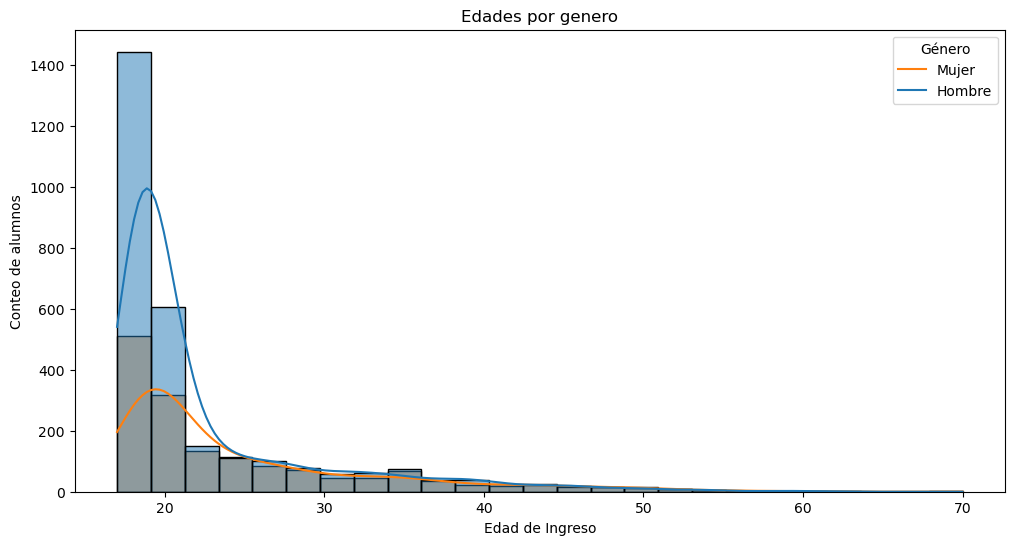

In [59]:
plt.figure(figsize =(12,6))
sns.histplot(
    data=df,
    x="Age at enrollment",
    hue="Gender",
    bins=25,
    kde=True
)
plt.legend(
    title="Género",
    labels=["Mujer","Hombre"]
)
plt.title("Edades por genero")
plt.xlabel("Edad de Ingreso")
plt.ylabel("Conteo de alumnos")
plt.show()

## Boxplot
Como mencioné antes, este gráfico busca especifícamente los outliers para reconocer si hay algunos valores que puedan sesgar al modelo. Pero no se si es correcto usar las mismas variables de esta manera. Obviamente también vemos la mediana y los intercuartiles. Es justamente por eso que me genera duda, esta bien usar este gráfico para ver particularmente eso o con el histograma logramos ver suficiente como para identificar los outliers. La otra opción que vi, es el de violín pero se me complico bastante. Este gráfico siento que no lo utilicé en su mejor manera. Pero la información brindada nos sirve para entender la concentración de datos.

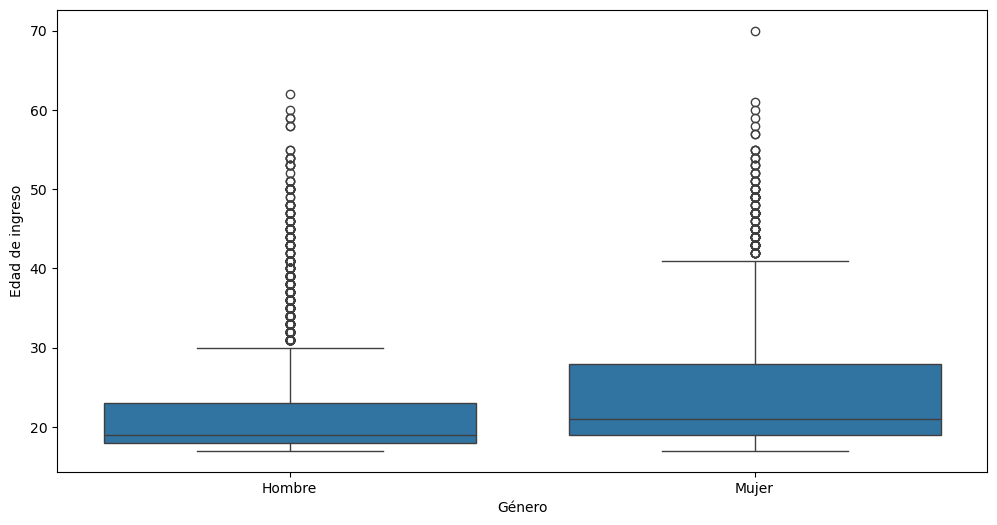

In [47]:
plt.figure(figsize =(12,6))
sns.boxplot(
    data=df,
    x="Gender",
    y="Age at enrollment"
)
plt.xticks(
    [0,1],
    ["Hombre","Mujer"]
)
plt.xlabel("Género")
plt.ylabel("Edad de ingreso")
plt.show()

## ScatterPlot
Con las variables con las que venía trabajando no se me ocurrió tanto como usarlas en el scatterPlot, por eso se me ocurrió utilizar las variables que mencionan a que se anotaron y que aprobaron, me parece que es un buen indicador para analizar en el futuro analizar si los hombres con más semestres desaprobados tienden a abandonar.

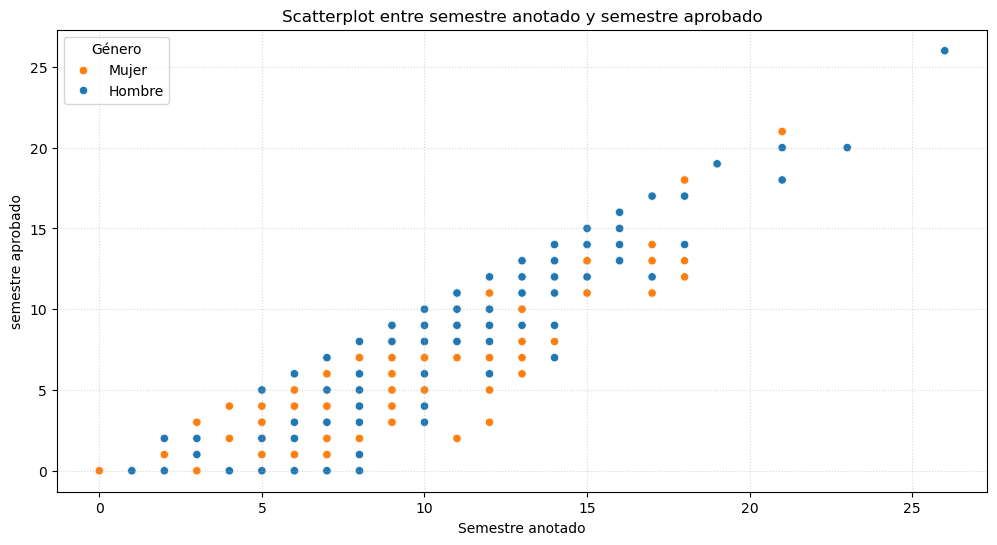

In [61]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df,
    x="Curricular units 1st sem (enrolled)",
    y="Curricular units 1st sem (approved)",
    hue="Gender"
)
plt.legend(
    title="Género",
    labels=["Mujer","Hombre"]
)
plt.title("Scatterplot entre semestre anotado y semestre aprobado")
plt.xlabel("Semestre anotado")
plt.ylabel("semestre aprobado")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

### Conclusión
Me falta mucho para comprender lo necesario pero creo que esta es una buena aproximación, también creo que falta moldear un poco mejor los datos y siento que no comprendí del todo el potencial del dataset, también siento que me falta práctica para entender del todo bien que usar y cuando usar pero creo que fue una buena base, espero las correcciones. Muchas gracias!